In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sys.path.append('..')
from src.utility.utils import get_data_loaders
from src.utility.config import IMAGE_SIZE

In [3]:
train_loader, test_loader, num_classes = get_data_loaders()

print(f"Anzahl Klassen: {num_classes}")
print(f"Batch Size: {train_loader.batch_size}")

data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"Bild Form: {images.shape}") # Sollte sein: [64, 3, 64, 64]

Anzahl Klassen: 150
Batch Size: 64
Bild Form: torch.Size([64, 3, 64, 64])


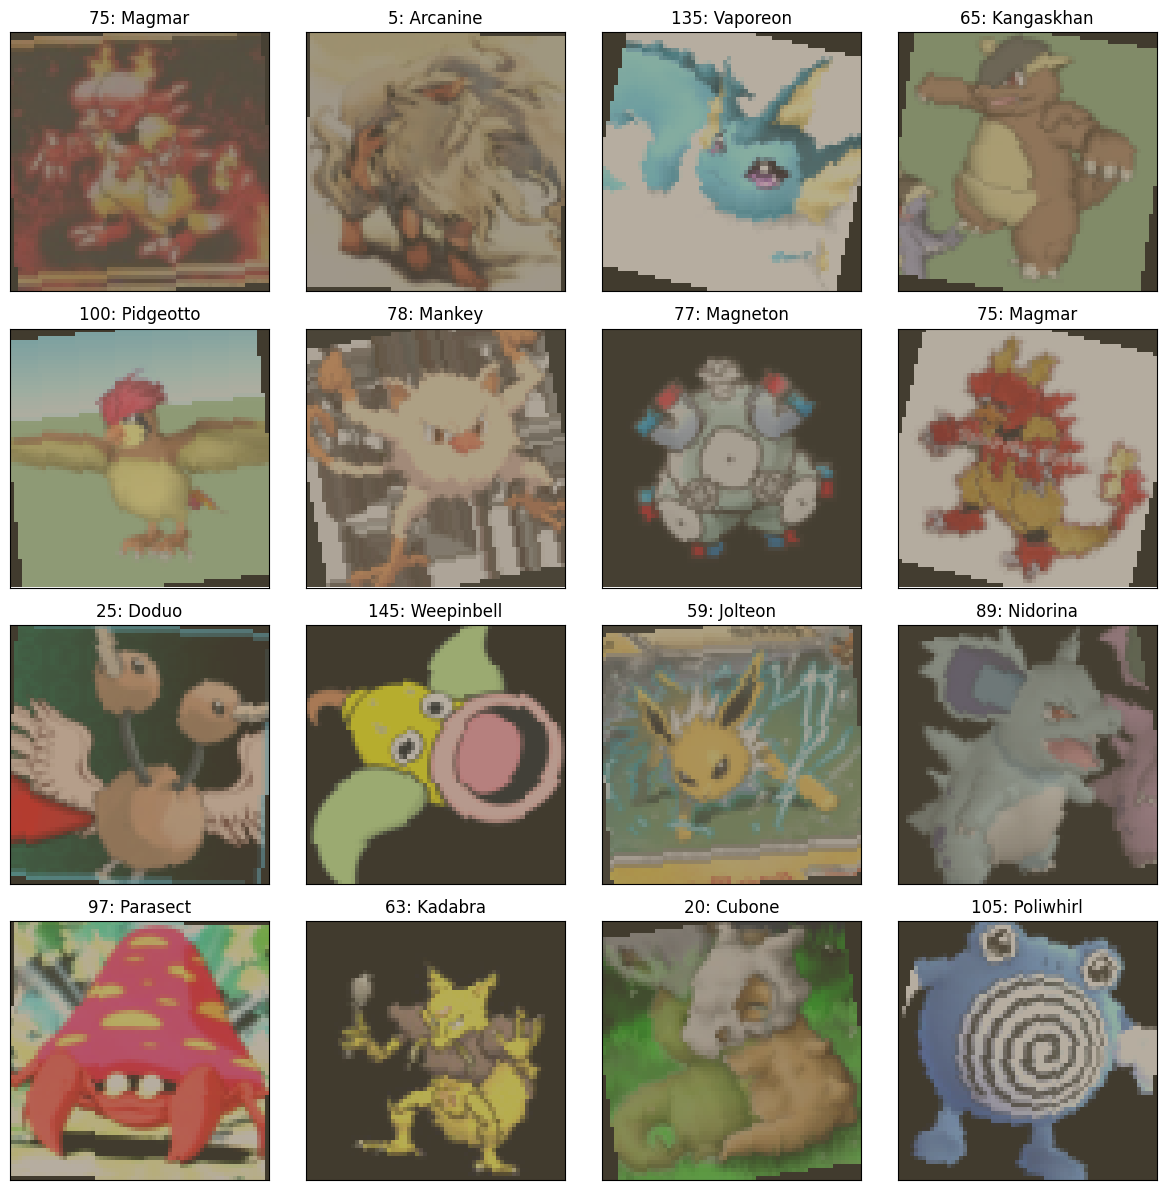

In [4]:
# Zelle 4
def imshow(img):
    # Konvertieren von Tensor (C, H, W) zu Numpy (H, W, C)
    img = img.numpy().transpose((1, 2, 0))
    
    # Denormalisieren (ungefähr, basierend auf ImageNet Stats)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    
    # Werte auf 0-1 beschränken für saubere Anzeige
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)

# Wir holen uns die Klassennamen aus dem Dataset
# (Da train_loader ein Subset ist, müssen wir etwas tiefer graben)
if hasattr(train_loader.dataset, 'dataset'):
    class_names = train_loader.dataset.dataset.classes
else:
    class_names = train_loader.dataset.classes

fig = plt.figure(figsize=(12, 12))
for i in range(16):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    imshow(images[i])
    
    # Label ID und echter Name
    label_id = labels[i].item()
    pokemon_name = class_names[label_id]
    ax.set_title(f"{label_id}: {pokemon_name}")

plt.tight_layout()
plt.show()

Minimale Bilder pro Klasse: 21
Maximale Bilder pro Klasse: 52


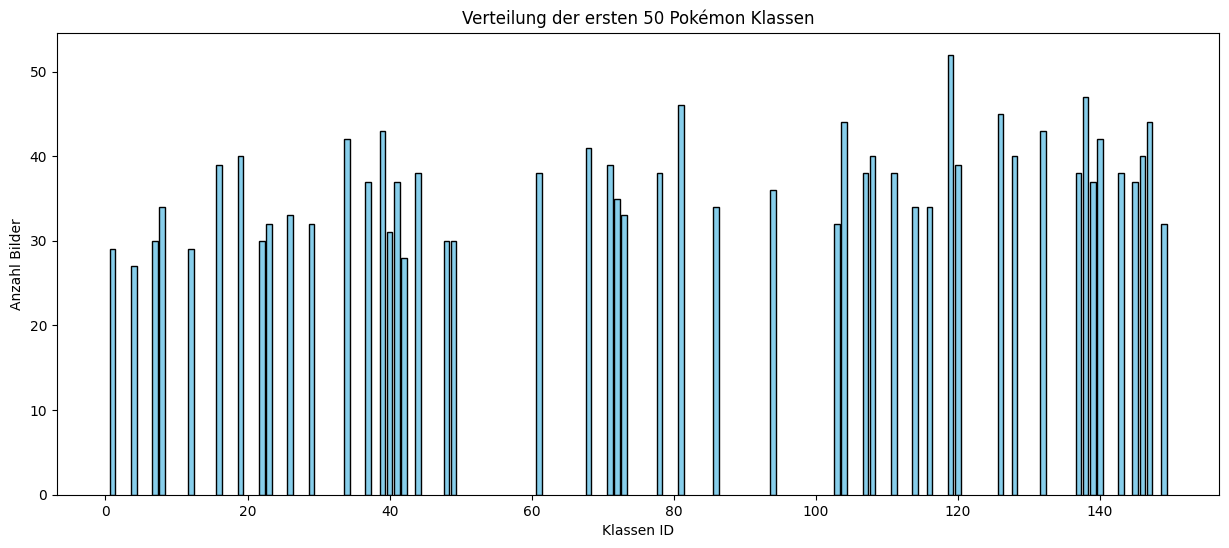

In [5]:
# Zelle 5
from collections import Counter

# Wir holen alle Labels aus dem Dataset (dauert kurz)
# Achtung: Bei Subsets (random_split) greifen wir auf indices zu
if hasattr(train_loader.dataset, 'indices'):
    all_indices = train_loader.dataset.indices
    # Zugriff auf die Targets des Original-Datasets über die Indizes
    all_labels = [train_loader.dataset.dataset.targets[i] for i in all_indices]
else:
    all_labels = train_loader.dataset.targets

# Zählen
counts = Counter(all_labels)
labels_list = list(counts.keys())
values_list = list(counts.values())

print(f"Minimale Bilder pro Klasse: {min(values_list)}")
print(f"Maximale Bilder pro Klasse: {max(values_list)}")

plt.figure(figsize=(15, 6))
# Wir plotten nur die ersten 50 Klassen, damit man was erkennt
plt.bar(labels_list[:50], values_list[:50], color='skyblue', edgecolor='black')
plt.title("Verteilung der ersten 50 Pokémon Klassen")
plt.xlabel("Klassen ID")
plt.ylabel("Anzahl Bilder")
plt.show()